In [104]:
from pathlib import Path
import pandas as pd
import json
import numpy as np
import torch
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
from datasets import load_dataset

In [105]:
from read_outputs import read_results, load_mc_harm_estimates, judge_threshold_ablation

model_outputs/Llama-3.2-1B-Instruct
Found valid model logs, with length = 271


/tmp/ipykernel_2604484/2982545491.py:28: RuntimeWarning: divide by zero encountered in log10
  plt.scatter(np.log10(is_score_arr), (mc_score_arr))


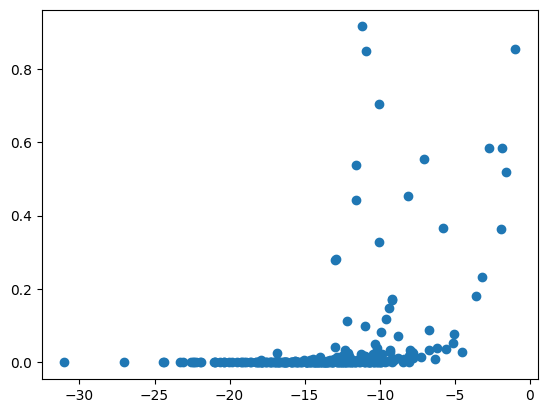

model_outputs/meta-llama-3-8b-instruct
Found valid model logs, with length = 313


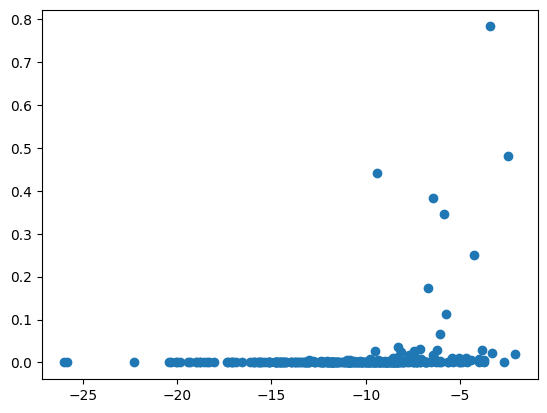

model_outputs/gemma-2-2b-it
Found valid model logs, with length = 271


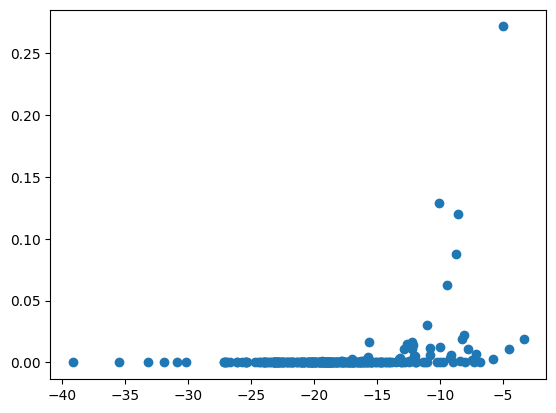

In [121]:
output_path = "./model_outputs"
mc_harm_path = "./monte_carlo_estimates/results/strong_reject/"

model_name_arr = list(Path(output_path).iterdir())

# model_name = "meta-llama-3-8b-instruct"

for model_name in model_name_arr:
    print(model_name)
    
    mc_harm_estimates = load_mc_harm_estimates(mc_harm_path, model_name.name)
    is_model_logs = read_results(
        output_path=output_path,
        model_name=model_name.name,
        mc_harm_estimates=mc_harm_estimates,
    )            

    judge_arr = judge_threshold_ablation(mc_scores=mc_harm_estimates, is_scores=is_model_logs)

    mc_score_arr, is_score_arr = [], []
    for idx in range(len(judge_arr)):
    
        mc_score_arr.append(judge_arr[idx]['mc_score_mean'])    
        is_score_arr.append(judge_arr[idx]['is_score_mean'])

    # plt.plot(np.linspace(0,1,100), np.linspace(0,1,100))
    # print(is_score_arr)
    plt.scatter(np.log10(is_score_arr), np.log10(mc_score_arr))
    plt.show()

In [112]:
is_model_logs

In [54]:
# mc_harm_estimates[0].keys()

dict_keys(['forbidden_prompt', 'harm_scores', 'harm_mean', 'harm_var'])

In [55]:
# len(is_model_logs[0]['new_harm_estimates_200_0_judge_scores']), len(is_model_logs[0]['new_harm_estimates_200_0_importance_weights'])

(200, 200)

In [103]:
# np.array(is_model_logs[0]['new_harm_estimates_200_0_judge_scores']) * np.array(is_model_logs[0]['new_harm_estimates_200_0_importance_weights'])

In [57]:
len(mc_harm_estimates[0]['harm_scores'])

10000

In [58]:
is_model_logs[0]['Forbidden prompt'] == mc_harm_estimates[0]['forbidden_prompt']

True

In [77]:
mc_score_arr

[]